In [8]:
import os
import copy
import numpy as np
import pandas as pd
import geopandas as gpd

from pathlib import Path

from src import utils, stats_utils
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=1.25)

from src.data.lfs import EulfsDs

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
config_paths = "paths_config.yml"
config_data = "data_config.yml"

In [13]:
eulfs = EulfsDs(fn_config_path=config_paths, fn_config_data=config_data)

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [19]:
fpath_fr = r"C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles\FR_YEAR_1998_onwards\FR2019_y.csv"
fpath_de = r"C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles\DE_YEAR_1998_onwards\DE2019_y.csv"
fpath_pl = r"C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles\PL_YEAR_1998_onwards\PL2019_y.csv"
fpath_bg = r"C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles\BG_YEAR_1998_onwards\BG2019_y.csv"


In [4]:
cntry = "MT"
fpath = r"C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles" \
        r"\{}_YEAR_1998_onwards\{}2019_y.csv".format(cntry, cntry)

df = pd.read_csv(fpath, usecols=eulfs.variables, na_values=eulfs.na_values,
                 dtype=eulfs.dtypes_in)
df[df.COUNTRYW == '000-OWN COUNTRY']
df

,SEX,WSTATOR,NACE1D,ISCO3D,COUNTRYW,REGIONW,FTPT,REFYEAR,COUNTRY,REGION,DEGURBA,HHTYPE,COEFF,AGE,ILOSTAT,EDUC4WN,HATLEV1D,MAINSTAT,INCDECIL
0,1,5,NaN,NaN,NOT APPLICABLE,NaN,NaN,2019,MT,NaN,1,1,0.01375,77,3,0,M,4,NaN
1,2,5,NaN,NaN,NOT APPLICABLE,NaN,NaN,2019,MT,NaN,1,1,0.01100,77,3,0,M,4,NaN
2,2,5,NaN,NaN,NOT APPLICABLE,NaN,NaN,2019,MT,NaN,1,1,0.01600,47,3,0,L,7,NaN
3,1,1,H,800,000-OWN COUNTRY,NaN,1,2019,MT,NaN,1,1,0.01225,52,1,0,L,1,08
4,1,5,NaN,NaN,NOT APPLICABLE,NaN,NaN,2019,MT,NaN,1,1,0.01725,22,2,1,L,8,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20971,1,1,K,100,000-OWN COUNTRY,NaN,1,2019,MT,NaN,2,1,0.02250,57,1,0,M,1,10
20972,2,1,K,300,000-OWN COUNTRY,NaN,1,2019,MT,NaN,2,1,0.01875,52,1,0,M,1,08
20973,1,1,C,200,000-OWN COUNTRY,NaN,1,2019,MT,NaN,2,1,0.03250,27,1,0,H,1,08
20974,2,5,NaN,NaN,NOT APPLICABLE,NaN,NaN,2019,MT,NaN,2,1,0.04875,37,2,1,L,2,NaN


In [14]:
df_all = eulfs.read(year=2019, covariates=True)

In [27]:
col = "isco_label_2"
df_all.dropna(subset=[col])

,SEX,WSTATOR,NACE1D,ISCO3D,COUNTRYW,REGIONW,FTPT,REFYEAR,COUNTRY,REGION,...,isco_label_2,isco_level_3,isco_label_3,isco_level_4,isco_label_4,NACE1D_label,COEFF_share_green_gtp_mean,COEFF_share_green_esco_mean,COEFF_share_brown_esco_mean,COEFF_share_neutral_esco_mean
105810,1,1,G,140,BG,41,1,2019,BG,41,...,"Hospitality, retail and other services managers",NaN,NaN,NaN,NaN,Wholesale and Retail Trade; Repair of Motor Ve...,20.997647,6.717179,0.123944,171.638876
105811,2,1,G,520,BG,41,2,2019,BG,41,...,Sales workers,NaN,NaN,NaN,NaN,Wholesale and Retail Trade; Repair of Motor Ve...,22.438824,0.786583,0.075408,189.868009
105812,2,2,O,240,BG,41,1,2019,BG,41,...,Business and administration professionals,NaN,NaN,NaN,NaN,Public Administration and Defence; Compulsory ...,44.784187,4.250459,0.000000,186.479541
105813,1,1,F,310,BG,41,1,2019,BG,41,...,Science and engineering associate professionals,NaN,NaN,NaN,NaN,Construction,76.259605,18.429705,4.584653,187.635642
105814,2,1,F,130,BG,41,1,2019,BG,41,...,Production and specialised services managers,NaN,NaN,NaN,NaN,Construction,73.501237,7.456931,1.761546,217.051523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1243074,1,1,F,830,PL,42,1,2019,PL,42,...,Drivers and mobile plant operators,NaN,NaN,NaN,NaN,Construction,32.898871,5.544323,3.635147,136.515529
1243075,2,2,C,820,PL,42,1,2019,PL,42,...,Assemblers,NaN,NaN,NaN,NaN,Manufacturing,28.333000,5.230058,8.266981,199.000462
1243076,1,1,C,810,PL,42,1,2019,PL,42,...,Stationary plant and machine operators,NaN,NaN,NaN,NaN,Manufacturing,16.863337,12.502759,31.380099,277.817142
1243077,2,1,C,750,PL,42,1,2019,PL,42,...,"Food processing, wood working, garment and oth...",NaN,NaN,NaN,NaN,Manufacturing,13.125794,8.419019,3.862762,201.118219


In [7]:
def perc_missing(df):
    return df.isna().sum() / df.shape[0]

perc_missing(df_all)

SEX                                0.000000
WSTATOR                            0.000000
NACE1D                             0.003823
ISCO3D                             0.000000
COUNTRYW                           0.000000
                                     ...   
COEFF_share_brown_esco_iqr         0.010458
COEFF_share_neutral_esco_mean      0.010458
COEFF_share_neutral_esco_std       0.034960
COEFF_share_neutral_esco_median    0.010458
COEFF_share_neutral_esco_iqr       0.010458
Length: 64, dtype: float64

In [24]:
countries = ["NL"]
perc_missing(df_all.loc[df_all["COUNTRY"].isin(countries)])

SEX                                0.000000
WSTATOR                            0.000000
NACE1D                             0.090380
ISCO3D                             0.000000
COUNTRYW                           0.000000
                                     ...   
COEFF_share_brown_esco_iqr         0.015414
COEFF_share_neutral_esco_mean      0.015414
COEFF_share_neutral_esco_std       0.029811
COEFF_share_neutral_esco_median    0.015414
COEFF_share_neutral_esco_iqr       0.015414
Length: 64, dtype: float64

In [25]:
ix_isco = df_all.loc[:, "ISCO3D"].sort_values().index.values
df_all.iloc[ix_isco]

,SEX,WSTATOR,NACE1D,ISCO3D,COUNTRYW,REGIONW,FTPT,REFYEAR,COUNTRY,REGION,...,COEFF_share_green_esco_median,COEFF_share_green_esco_iqr,COEFF_share_brown_esco_mean,COEFF_share_brown_esco_std,COEFF_share_brown_esco_median,COEFF_share_brown_esco_iqr,COEFF_share_neutral_esco_mean,COEFF_share_neutral_esco_std,COEFF_share_neutral_esco_median,COEFF_share_neutral_esco_iqr
1478168,1,1,O,000,SK,04,1,2019,SK,04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1171912,1,1,O,000,PL,61,1,2019,PL,61,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1084604,1,1,O,000,MT,NaN,1,2019,MT,NaN,...,0.0,0.000000,0.030378,0.139208,0.0,0.0,18.418138,0.209708,18.5000,0.000000
1084599,1,1,O,000,MT,NaN,1,2019,MT,NaN,...,0.0,0.000000,0.069787,0.319802,0.0,0.0,42.311939,0.481763,42.5000,0.000000
1483567,1,1,O,000,SK,04,1,2019,SK,04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
890975,1,1,H,962,IT,G1,2,2019,IT,G1,...,0.0,1.942648,0.420032,1.455034,0.0,0.0,63.362444,4.166607,65.5250,2.759885
890985,1,1,T,962,IT,G1,1,2019,IT,G1,...,0.0,2.711999,0.586378,2.031274,0.0,0.0,88.456002,5.816717,91.4750,3.852887
1244683,1,1,O,962,PT,17,1,2019,PT,17,...,0.0,2.645960,0.572099,1.981810,0.0,0.0,86.302017,5.675075,89.2475,3.759066
889573,1,1,N,962,IT,C4,1,2019,IT,C4,...,0.0,1.081390,0.233814,0.809956,0.0,0.0,35.271196,2.319374,36.4750,1.536311


In [26]:
cols = ["COEFF_share_green_esco_mean", "COEFF_share_brown_esco_mean",
        "COEFF_share_neutral_esco_mean"]

np.allclose(df_all.loc[:, cols].sum(axis=1), df_all.COEFF)
error = np.abs(df_all.loc[:, cols].sum(axis=1) - df_all.COEFF)

df_all.iloc[error.sort_values(ascending=False).index.values]

,SEX,WSTATOR,NACE1D,ISCO3D,COUNTRYW,REGIONW,FTPT,REFYEAR,COUNTRY,REGION,...,COEFF_share_green_esco_median,COEFF_share_green_esco_iqr,COEFF_share_brown_esco_mean,COEFF_share_brown_esco_std,COEFF_share_brown_esco_median,COEFF_share_brown_esco_iqr,COEFF_share_neutral_esco_mean,COEFF_share_neutral_esco_std,COEFF_share_neutral_esco_median,COEFF_share_neutral_esco_iqr
529228,1,1,H,410,ES,61,1,2019,ES,61,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
596096,2,1,NaN,000,FR,E1,2,2019,FR,E1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
539025,2,2,I,410,ES,30,1,2019,ES,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
535198,2,1,S,410,ES,51,1,2019,ES,51,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
548848,2,2,L,410,ES,30,1,2019,ES,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
565090,1,1,G,522,ES,21,1,2019,ES,21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
565091,1,1,C,332,ES,51,1,2019,ES,21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
565092,2,1,S,514,ES,21,1,2019,ES,21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
565095,1,1,G,723,ES,24,1,2019,ES,24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Group by LFS variables

In [27]:
age_by_gbn_shares = df_all.groupby("AGE")["COEFF_share_green_esco_mean",
                           "COEFF_share_brown_esco_mean",
                      "COEFF_share_neutral_esco_mean"].sum()

coeff_by_age = df_all.groupby("AGE")["COEFF"].sum()

C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_10884\3363292881.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  age_by_gbn_shares = df_all.groupby("AGE")["COEFF_share_green_esco_mean",


In [28]:
age_by_gbn_shares_rel = age_by_gbn_shares.copy()
for col in age_by_gbn_shares_rel.columns:
    age_by_gbn_shares_rel[col] = age_by_gbn_shares_rel[col] / coeff_by_age

In [38]:
age_by_gbn_shares_rel

,COEFF_share_green_esco_mean,COEFF_share_brown_esco_mean,COEFF_share_neutral_esco_mean
AGE,,,
17,0.037356,0.013639,0.942190
22,0.035036,0.014717,0.945911
27,0.035378,0.013889,0.945189
32,0.036670,0.013594,0.943112
37,0.037622,0.013591,0.942746
42,0.038605,0.013792,0.940969
47,0.039654,0.014099,0.939980
52,0.040693,0.013859,0.939299
57,0.041822,0.013975,0.938003


<AxesSubplot:xlabel='AGE'>

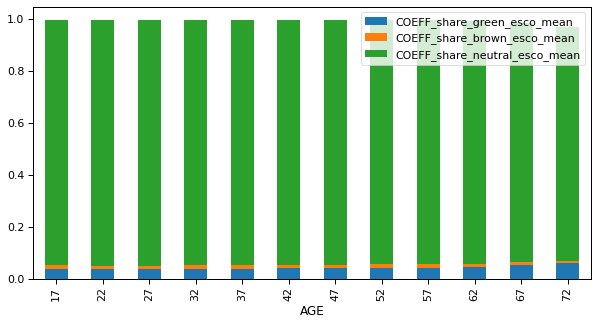

In [32]:
age_by_gbn_shares_rel.plot.bar(stacked=True, figsize=(10, 5))